# Python Graphs Every Data Analyst Should Know

This notebook covers the core Python visualization libraries and chart types that data analysts use daily. It includes examples for Matplotlib, Seaborn, and Plotly, with explanations of when to use each chart.

## 1. Setup and imports

Import the visualization libraries and prepare a sample dataset.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid')

data = pd.DataFrame({
    'order_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008],
    'customer': ['Alice', 'Bob', 'Charlie', 'Dana', 'Eli', 'Fiona', 'George', 'Helen'],
    'product': ['Widget', 'Gadget', 'Widget', 'Doohickey', 'Gadget', 'Widget', 'Gadget', 'Doohickey'],
    'quantity': [4, 2, 1, 3, 5, 2, 4, 3],
    'price': [20.5, 15.0, 20.5, 12.0, 15.0, 20.5, 15.0, 12.0],
    'status': ['Delivered', 'Returned', 'Processing', 'Delivered', 'Delivered', 'Delivered', 'Returned', 'Processing'],
    'order_date': pd.to_datetime(['2024-06-01', '2024-06-03', '2024-06-05', '2024-06-07', '2024-06-10', '2024-06-12', '2024-06-14', '2024-06-18'])
})

data['total'] = data['quantity'] * data['price']
data['order_month'] = data['order_date'].dt.to_period('M')
data.head()

,order_id,customer,product,quantity,price,status,order_date,total,order_month
0,1001,Alice,Widget,4,20.5,Delivered,2024-06-01,82.0,2024-06
1,1002,Bob,Gadget,2,15.0,Returned,2024-06-03,30.0,2024-06
2,1003,Charlie,Widget,1,20.5,Processing,2024-06-05,20.5,2024-06
3,1004,Dana,Doohickey,3,12.0,Delivered,2024-06-07,36.0,2024-06
4,1005,Eli,Gadget,5,15.0,Delivered,2024-06-10,75.0,2024-06


## 2. Bar charts for comparisons

Bar charts are the most common charts for comparing categories. Use them for revenue by product, sales by customer, or counts by status.

C:\Users\CAMAJUL\AppData\Local\Temp\ipykernel_5724\2705259335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_product, x='product', y='total', palette='pastel')


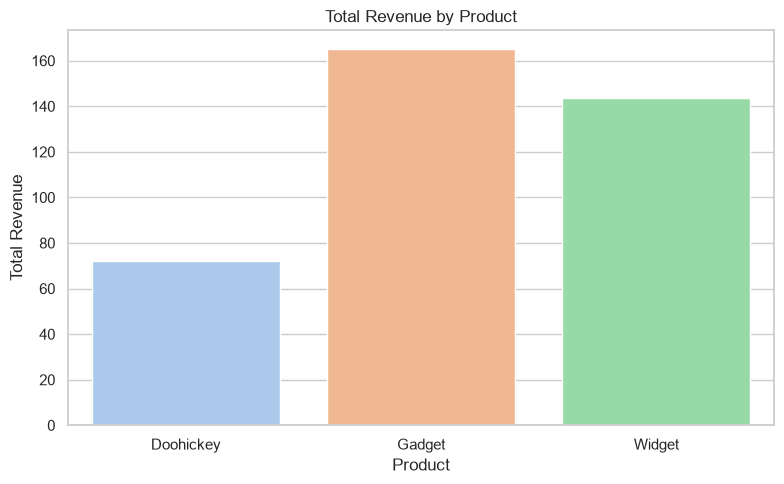

In [3]:
revenue_by_product = data.groupby('product', as_index=False)['total'].sum()
revenue_by_product

plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_by_product, x='product', y='total', palette='pastel')
plt.title('Total Revenue by Product')
plt.ylabel('Total Revenue')
plt.xlabel('Product')
plt.tight_layout()
plt.show()

## 3. Line charts for trends

Line charts are ideal for showing trends over time, such as monthly revenue or daily orders.

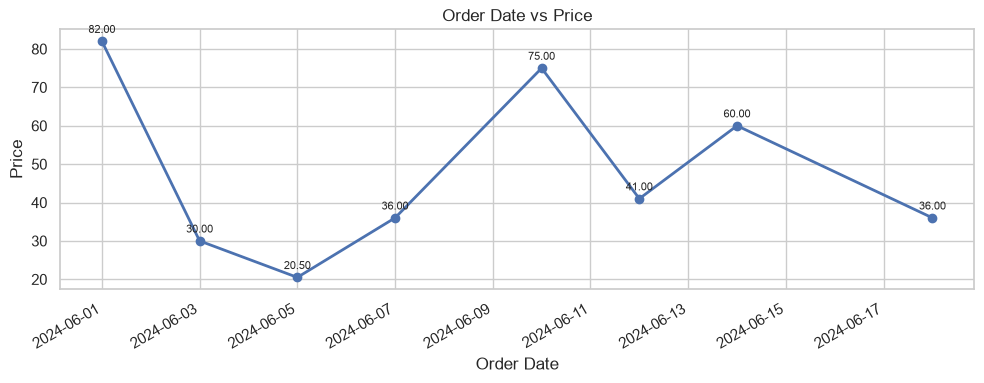

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = data.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date')

plt.figure(figsize=(10,4))
plt.plot(df['order_date'], df['total'], marker='o', linewidth=2)
plt.title('Order Date vs Price')
plt.ylabel('Price')
plt.xlabel('Order Date')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()

for x, y in zip(df['order_date'], df['total']):
    ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Histograms and distribution plots

Use histograms and KDE plots to understand numeric distributions like order totals or quantity.

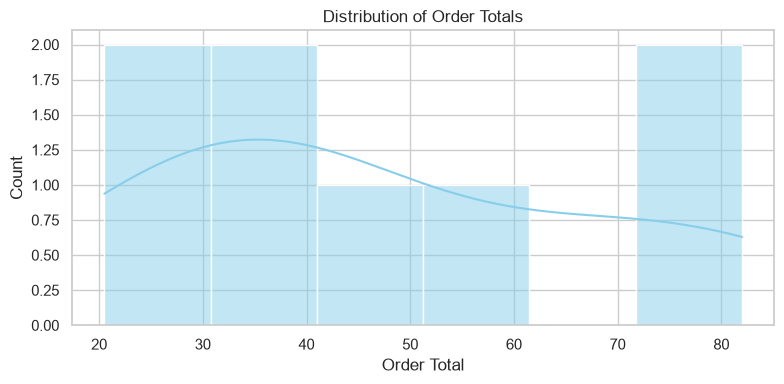

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x='total', kde=True, bins=6, color='skyblue')
plt.title('Distribution of Order Totals')
plt.xlabel('Order Total')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Scatter plots for relationships

Scatter plots help identify relationships between two numeric variables, such as quantity and total value.

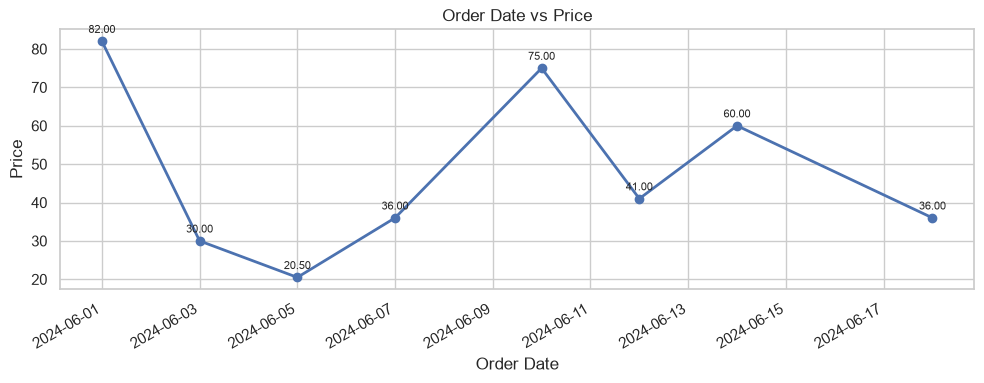

In [19]:
import matplotlib.dates as mdates

# Annotated time-series: order_date vs price (total)
df = data.copy()
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date')

plt.figure(figsize=(10,4))
plt.plot(df['order_date'], df['total'], marker='o', linewidth=2)
plt.title('Order Date vs Price')
plt.ylabel('Price')
plt.xlabel('Order Date')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()

for x, y in zip(df['order_date'], df['total']):
    ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Box plots for variation

Box plots show distribution and outliers across categories, useful for comparing order totals by product or status.

C:\Users\CAMAJUL\AppData\Local\Temp\ipykernel_5724\2498181827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='product', y='total', palette='Set2')


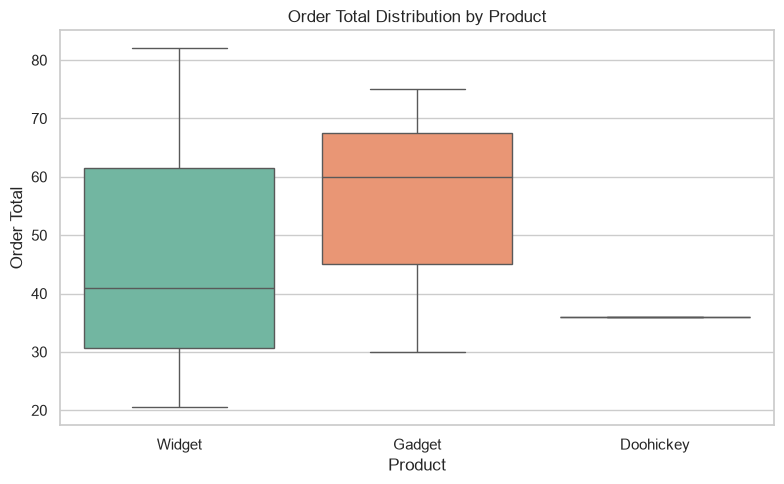

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='product', y='total', palette='Set2')
plt.title('Order Total Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Order Total')
plt.tight_layout()
plt.show()

## 7. Categorical plots

Count plots and bar plots make it easy to compare categorical frequencies like order status or product counts.

C:\Users\CAMAJUL\AppData\Local\Temp\ipykernel_5724\2573028159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='status', palette='muted')


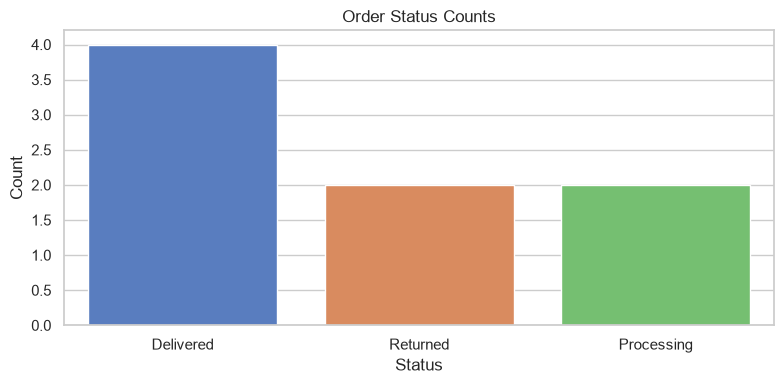

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='status', palette='muted')
plt.title('Order Status Counts')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 8. Heatmaps for correlation and cross-tab analysis

Heatmaps are useful for correlation matrices or cross-tabulated counts.

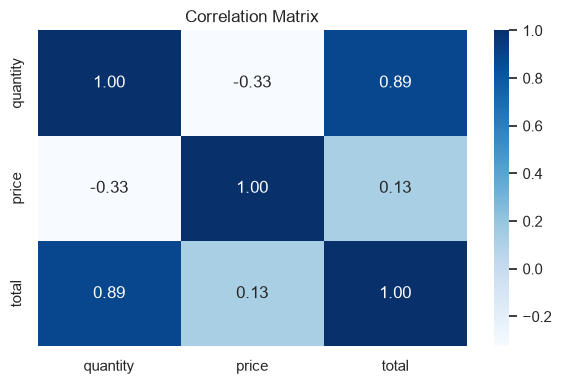

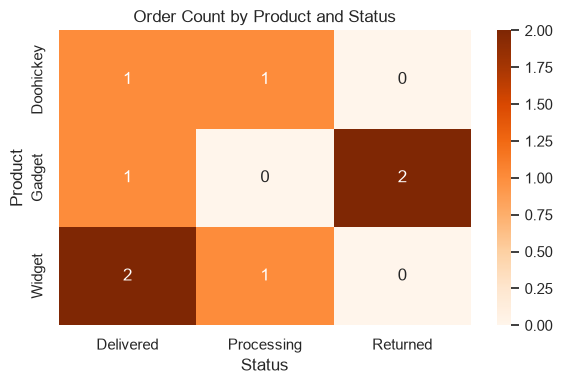

In [17]:
correlation = data[['quantity', 'price', 'total']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

pivot = data.pivot_table(index='product', columns='status', values='order_id', aggfunc='count', fill_value=0)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Oranges')
plt.title('Order Count by Product and Status')
plt.ylabel('Product')
plt.xlabel('Status')
plt.tight_layout()
plt.show()

## 10. Saving charts and outputs

Save the final charts to files for reports or presentations.

C:\Users\CAMAJUL\AppData\Local\Temp\ipykernel_5724\2278077083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_product, x='product', y='total', palette='pastel')


Saved chart to revenue_by_product.png


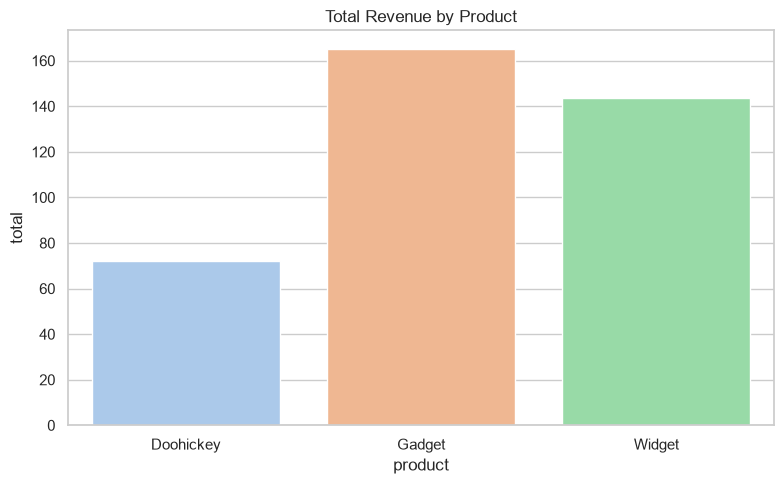

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=revenue_by_product, x='product', y='total', palette='pastel')
plt.title('Total Revenue by Product')
plt.tight_layout()
plt.savefig('revenue_by_product.png', dpi=150)
print('Saved chart to revenue_by_product.png')